In [1]:
import control as ct
import matplotlib.pyplot as plt

In [2]:
k = 2
tau = 3
s = ct.TransferFunction.s
G = k / (tau*s + 1)

In [3]:
# IMC tuning parameter
lambda_imc = 2

# IMC controller (for first-order system): inverse of the process with a low-pass filter
Gc = (tau*s + 1) / (k * (lambda_imc*s + 1))

In [4]:
T = ct.feedback(Gc * G)

print("Closed-loop transfer function:")
print(T)

Closed-loop transfer function:
<TransferFunction>: sys[19]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

       6 s + 2
  -----------------
  12 s^2 + 16 s + 4


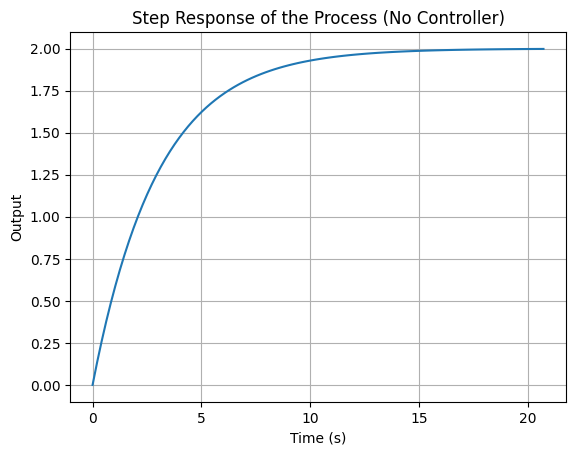

In [5]:
t, y = ct.step_response(G)

plt.plot(t, y)
plt.title('Step Response of the Process (No Controller)')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.grid()

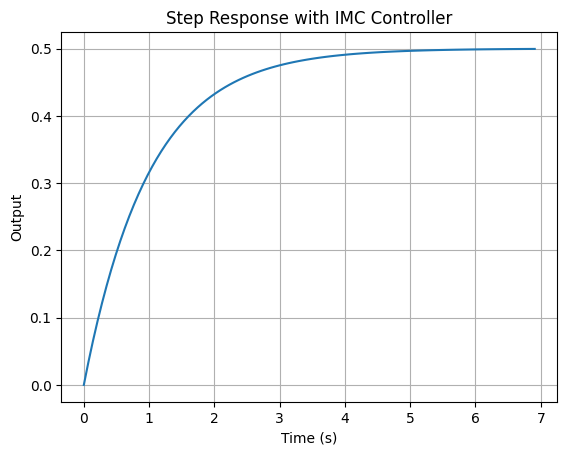

In [6]:
t, y = ct.step_response(T)

plt.plot(t, y)
plt.title('Step Response with IMC Controller')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.grid()

IMC designs controller based on model inversion + filtering

λ (lambda) controls trade-off:
* small → fast, aggressive
* large → slow, robust

Closed-loop transfer function:
<TransferFunction>: sys[37]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

      6 s + 2
  ----------------
  3 s^2 + 13 s + 4


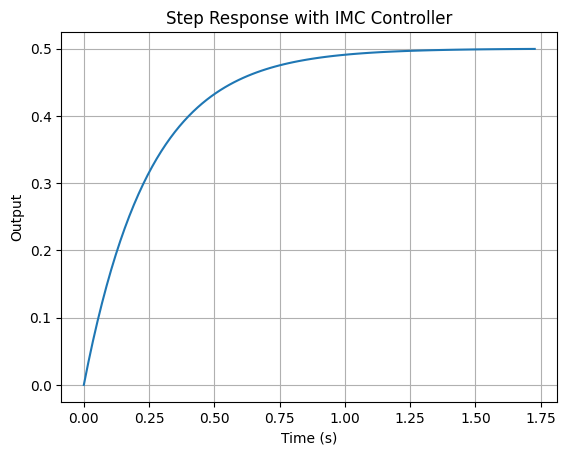

In [7]:
lambda_imc = 0.5
Gc = (tau*s + 1) / (k * (lambda_imc*s + 1))
T = ct.feedback(Gc * G)
print("Closed-loop transfer function:")
print(T)
t, y = ct.step_response(T)
plt.plot(t, y)
plt.title('Step Response with IMC Controller')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.grid()